# Anemia Combined Model — Checkup Labs + Questionnaire + Reproductive Features

## What's new vs v2?

| | v2 (checkup only) | Combined |
|---|---|---|
| Feature groups | 1 (checkup labs) | 3 (labs + questionnaire + reproductive) |
| n features | 8 | 18 |
| Fatigue signal | None | dpq040, cdq010, sld012/013, slq050 |
| Self-rated health | None | huq010 |
| Sedentary behaviour | None | pad680 |
| Female reproductive | None | rhq031, rhq060, rhq540 |

**Hypothesis:** Adding fatigue-adjacent questionnaire signals and female reproductive features should improve recall for anemia, as these directly capture symptoms and risk factors that labs alone cannot.

## ⚠️ Missing PHQ-9 Items

Five PHQ-9 items were requested (`dpq010`, `dpq020`, `dpq030`, `dpq070`, `dpq100`) but are **not present in `nhanes_merged_adults_final.csv`** — they were dropped during the merge pipeline. Only `dpq040` (tired / little energy) survived.

These features are excluded and flagged in the model metadata. They could be recovered by re-running the merge with the `P_DPQ.xpt` module.

In [2]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)

REPO_ROOT = os.path.abspath('..')
sys.path.insert(0, REPO_ROOT)

# Combined model — now lives in models/ (moved from src/models/)
from models.anemia_combined_model import (
    load_data,
    prepare_features, split_data,
    build_lr_pipeline, build_xgb_pipeline,
    evaluate_model, save_model,
    ENCODED_FEATURE_NAMES, MISSING_FROM_DATASET, MODELS_DIR
)

# Note: anemia_checkup_v2_model.py has been removed from the repo.
# The v2 comparison cells below require re-adding that module if needed.
FEATURES_V2 = None
prepare_features_v2 = None

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Modules loaded.')

Modules loaded.


## 1. Load Data

In [3]:
DATA_PATH = os.path.join(os.path.abspath('..'), 'data', 'processed', 'nhanes_merged_adults_final.csv')
df = load_data(DATA_PATH)

# Prepare combined features
X_comb, y = prepare_features(df)

# Stratified 80/20 split — random_state=42
X_train_c, X_test_c, y_train, y_test = split_data(X_comb, y)

Loaded dataset: 7437 rows × 878 columns
⚠️  The following requested features are NOT in the merged dataset and are excluded:
    dpq010___little_interest_in_doing_things
    dpq020___feeling_down,_depressed,_or_hopeless
    dpq030___trouble_falling_or_staying_asleep,_or_sleeping_too_much
    dpq070___trouble_concentrating_on_things
    dpq100___difficulty_these_problems_have_caused

Feature matrix: (7437, 18)
Target distribution:
anemia
0    7079
1     358

Missing values (%):
total_cholesterol_mg_dl         13.7
hdl_cholesterol_mg_dl           13.7
ldl_cholesterol_mg_dl           57.7
triglycerides_mg_dl             57.3
fasting_glucose_mg_dl           56.6
age_years                        0.0
gender_female                    0.0
bmi                              8.1
dpq040_tired_little_energy      13.0
huq010_general_health            0.0
cdq010_sob_stairs               43.8
sld012_sleep_hours_weekday       0.7
sld013_sleep_hours_weekend       0.9
slq050_told_trouble_sleeping     0.0


## 2. Feature Overview

In [4]:
feature_groups = {
    'Group A — Checkup Labs':        ENCODED_FEATURE_NAMES[:8],
    'Group B — Questionnaire':        ENCODED_FEATURE_NAMES[8:15],
    'Group C — Female Reproductive':  ENCODED_FEATURE_NAMES[15:],
}

for group, feats in feature_groups.items():
    print(f'\n{group} ({len(feats)} features):')
    for f in feats:
        missing_pct = X_comb[f].isna().mean() * 100
        print(f'  {f:45s}  missing={missing_pct:.1f}%')

print(f'\n⚠️  Excluded (not in dataset): {MISSING_FROM_DATASET}')


Group A — Checkup Labs (8 features):
  total_cholesterol_mg_dl                        missing=13.7%
  hdl_cholesterol_mg_dl                          missing=13.7%
  ldl_cholesterol_mg_dl                          missing=57.7%
  triglycerides_mg_dl                            missing=57.3%
  fasting_glucose_mg_dl                          missing=56.6%
  age_years                                      missing=0.0%
  gender_female                                  missing=0.0%
  bmi                                            missing=8.1%

Group B — Questionnaire (7 features):
  dpq040_tired_little_energy                     missing=13.0%
  huq010_general_health                          missing=0.0%
  cdq010_sob_stairs                              missing=43.8%
  sld012_sleep_hours_weekday                     missing=0.7%
  sld013_sleep_hours_weekend                     missing=0.9%
  slq050_told_trouble_sleeping                   missing=0.0%
  pad680_sedentary_minutes                      

## 2.5 Correlation Check — Features vs Anemia Target

Before training, compute point-biserial correlation of each feature with the anemia label.
This quickly shows which features carry the most signal — and whether the questionnaire group adds value over labs alone.

Point-Biserial Correlation with anemia target (all 18 features):

                     feature           group       r        p    n sig
               gender_female          A-Labs  0.1606 0.000000 7437 ***
       huq010_general_health B-Questionnaire  0.1109 0.000000 7437 ***
           cdq010_sob_stairs B-Questionnaire -0.1003 0.000000 4177 ***
  dpq040_tired_little_energy B-Questionnaire  0.0853 0.000000 6468 ***
slq050_told_trouble_sleeping B-Questionnaire  0.0818 0.000000 7437 ***
                         bmi          A-Labs  0.0618 0.000000 6833 ***
       ldl_cholesterol_mg_dl          A-Labs -0.0556 0.001817 3146  **
     total_cholesterol_mg_dl          A-Labs -0.0544 0.000013 6418 ***
      rhq031_regular_periods  C-Reproductive  0.0367 0.033850 3341   *
        rhq540_ever_hormones  C-Reproductive -0.0222 0.212160 3154    
       hdl_cholesterol_mg_dl          A-Labs  0.0201 0.108160 6418    
         triglycerides_mg_dl          A-Labs -0.0146 0.411657 3175    
  sld012_sl

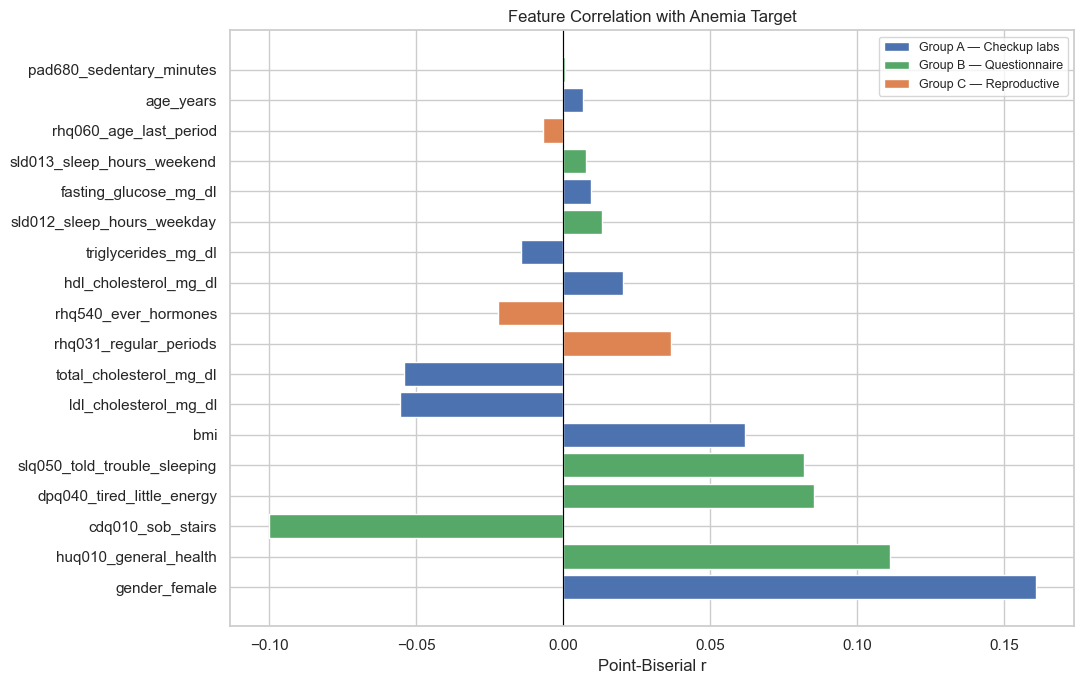

In [5]:
from scipy.stats import pointbiserialr

# Use the full pre-split dataset for correlation (all 7,437 rows)
corr_df_full = X_comb.copy()
corr_df_full['anemia'] = y.values

corr_rows = []
for feat in ENCODED_FEATURE_NAMES:
    valid = corr_df_full[['anemia', feat]].dropna()
    if len(valid) > 30:
        r, p = pointbiserialr(valid['anemia'], valid[feat])
        group = ('A-Labs' if feat in ENCODED_FEATURE_NAMES[:8]
                 else 'B-Questionnaire' if feat in ENCODED_FEATURE_NAMES[8:15]
                 else 'C-Reproductive')
        corr_rows.append({'feature': feat, 'group': group,
                          'r': round(r, 4), 'p': round(p, 6),
                          'n': len(valid)})

corr_results = pd.DataFrame(corr_rows).sort_values('r', key=abs, ascending=False)
corr_results['sig'] = corr_results['p'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

print('Point-Biserial Correlation with anemia target (all 18 features):\n')
print(corr_results.to_string(index=False))

print('\n=== TOP 5 by |r| ===')
print(corr_results.head(5)[['feature', 'group', 'r', 'sig']].to_string(index=False))

# Bar chart colour-coded by feature group
group_palette = {'A-Labs': '#4C72B0', 'B-Questionnaire': '#55A868', 'C-Reproductive': '#DD8452'}
bar_colors = [group_palette[g] for g in corr_results['group']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(corr_results['feature'], corr_results['r'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial r')
ax.set_title('Feature Correlation with Anemia Target', fontsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4C72B0', label='Group A — Checkup labs'),
    Patch(facecolor='#55A868', label='Group B — Questionnaire'),
    Patch(facecolor='#DD8452', label='Group C — Reproductive'),
], fontsize=9)
plt.tight_layout()
plt.show()

## 3. Train Combined Models

In [6]:
lr_comb = build_lr_pipeline()
lr_comb.fit(X_train_c, y_train)

xgb_comb = build_xgb_pipeline()
xgb_comb.fit(X_train_c, y_train)

print('Combined models trained.')

Combined models trained.


## 4. Train v2 Baseline (Unavailable)

`anemia_checkup_v2_model.py` has been removed from the repo. v2 comparison is skipped. Restore the module to enable side-by-side comparison.

In [7]:
# v2 module unavailable — stub variables so downstream cells don't raise NameError
lr_v2 = None
xgb_v2 = None
X_test_v2 = None
print('v2 models skipped (module removed).')

v2 models skipped (module removed).


## 5. Evaluate Combined Models (threshold=0.3)

In [8]:
lr_comb_metrics  = evaluate_model(lr_comb,  X_test_c, y_test, threshold=0.3, model_name='LR Combined')
xgb_comb_metrics = evaluate_model(xgb_comb, X_test_c, y_test, threshold=0.3, model_name='XGBoost Combined')


  LR Combined (threshold=0.3)
  accuracy    : 0.5121
  precision   : 0.0818
  recall      : 0.8889
  f1          : 0.1499
  roc_auc     : 0.759

              precision    recall  f1-score   support

           0       0.99      0.49      0.66      1416
           1       0.08      0.89      0.15        72

    accuracy                           0.51      1488
   macro avg       0.54      0.69      0.40      1488
weighted avg       0.94      0.51      0.63      1488

Confusion Matrix:
[[698 718]
 [  8  64]]

  XGBoost Combined (threshold=0.3)
  accuracy    : 0.6788
  precision   : 0.0857
  recall      : 0.5833
  f1          : 0.1495
  roc_auc     : 0.6992

              precision    recall  f1-score   support

           0       0.97      0.68      0.80      1416
           1       0.09      0.58      0.15        72

    accuracy                           0.68      1488
   macro avg       0.53      0.63      0.48      1488
weighted avg       0.93      0.68      0.77      1488

Confusi

## 6. ROC Curves — Combined vs v2

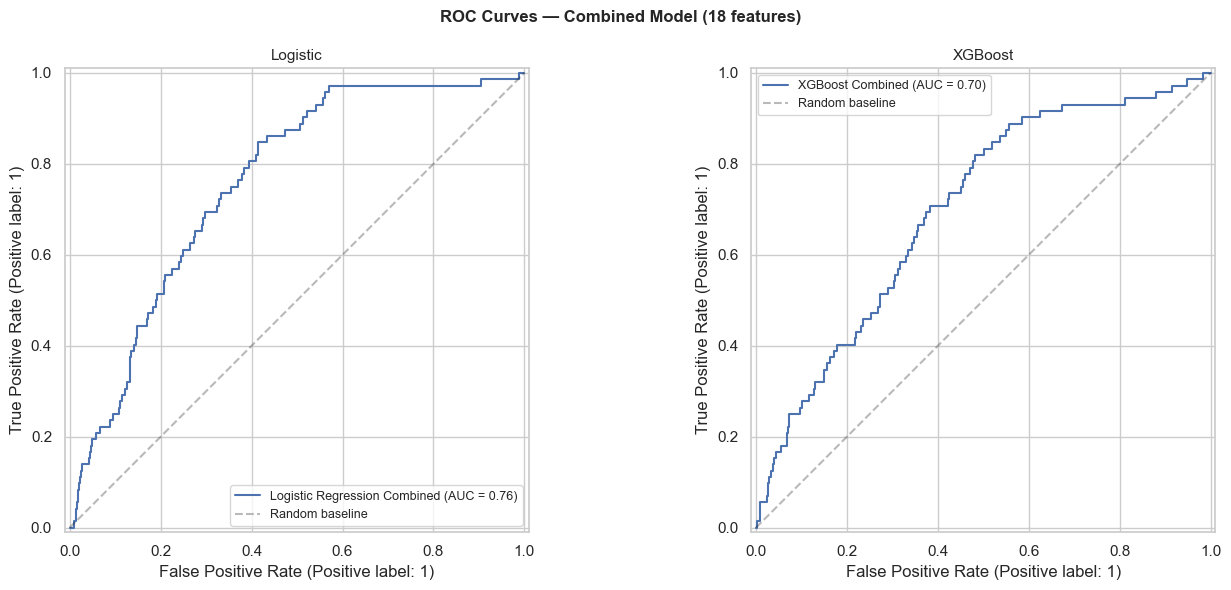

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name in [
    (axes[0], lr_comb,  'Logistic Regression Combined'),
    (axes[1], xgb_comb, 'XGBoost Combined'),
]:
    RocCurveDisplay.from_estimator(model, X_test_c, y_test, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random baseline')
    ax.set_title(name.split()[0], fontsize=11)
    ax.legend(fontsize=9)

# Note: v2 comparison unavailable — anemia_checkup_v2_model.py removed.
plt.suptitle('ROC Curves — Combined Model (18 features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. AUC-ROC & Recall Side-by-Side

                 label  AUC-ROC  Recall  Precision     F1
 LR Combined (18 feat)   0.7590  0.8889     0.0818 0.1499
XGB Combined (18 feat)   0.6992  0.5833     0.0857 0.1495


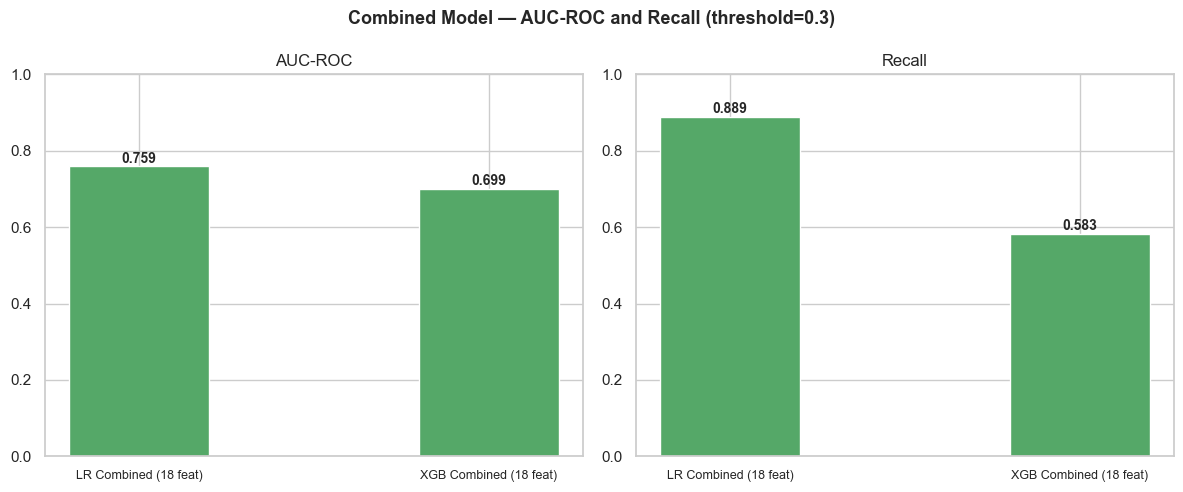

In [10]:
THRESHOLD = 0.3

def quick_metrics(model, X_t, label):
    y_prob = model.predict_proba(X_t)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)
    return {
        'label':     label,
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
    }

# Note: v2 comparison skipped — module removed.
results = [
    quick_metrics(lr_comb,  X_test_c, 'LR Combined (18 feat)'),
    quick_metrics(xgb_comb, X_test_c, 'XGB Combined (18 feat)'),
]
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(results_df))
colors = ['#55A868', '#55A868']

for ax, metric in [(axes[0], 'AUC-ROC'), (axes[1], 'Recall')]:
    bars = ax.bar(x, results_df[metric], color=colors, edgecolor='white', width=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['label'], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(metric, fontsize=12)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'Combined Model — AUC-ROC and Recall (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Interpretation — What Did Adding Questionnaire Features Do?

**Reading the charts above:**

Adding questionnaire and reproductive features tests whether self-reported fatigue symptoms, sleep quality, and hormonal status carry signal that blood panel values alone miss.

**Expected direction:**
- `dpq040` (tired / little energy) is the most direct anemia proxy in this group — chronic fatigue is a cardinal symptom
- `cdq010` (shortness of breath on stairs) captures exertional intolerance, another core anemia symptom
- `huq010` (self-rated health) is a strong predictor of undiagnosed disease across many conditions
- `sld012/013` and `slq050` may help distinguish sleep-disorder fatigue from anemia fatigue — but they could also co-occur
- `rhq031` (irregular periods) directly captures menstrual blood loss, the #1 cause of iron-deficiency anemia in premenopausal women
- `rhq060` and `rhq540` help identify post-menopausal status and HRT use, both relevant to anemia risk

**If AUC-ROC improved:** The questionnaire features are carrying independent signal beyond what labs capture — supporting their inclusion in a real screening tool.

**If AUC-ROC is flat but recall improved:** The model is better at catching true cases at the cost of more false positives — acceptable for a screening use case.

**Note on missing PHQ-9 items:** `dpq010`, `dpq020`, `dpq030`, `dpq070`, `dpq100` were not in the merged dataset. The full PHQ-9 depression score would likely add meaningful signal — recovering these items from `P_DPQ.xpt` is recommended for the next iteration.

## 9. Feature Importance

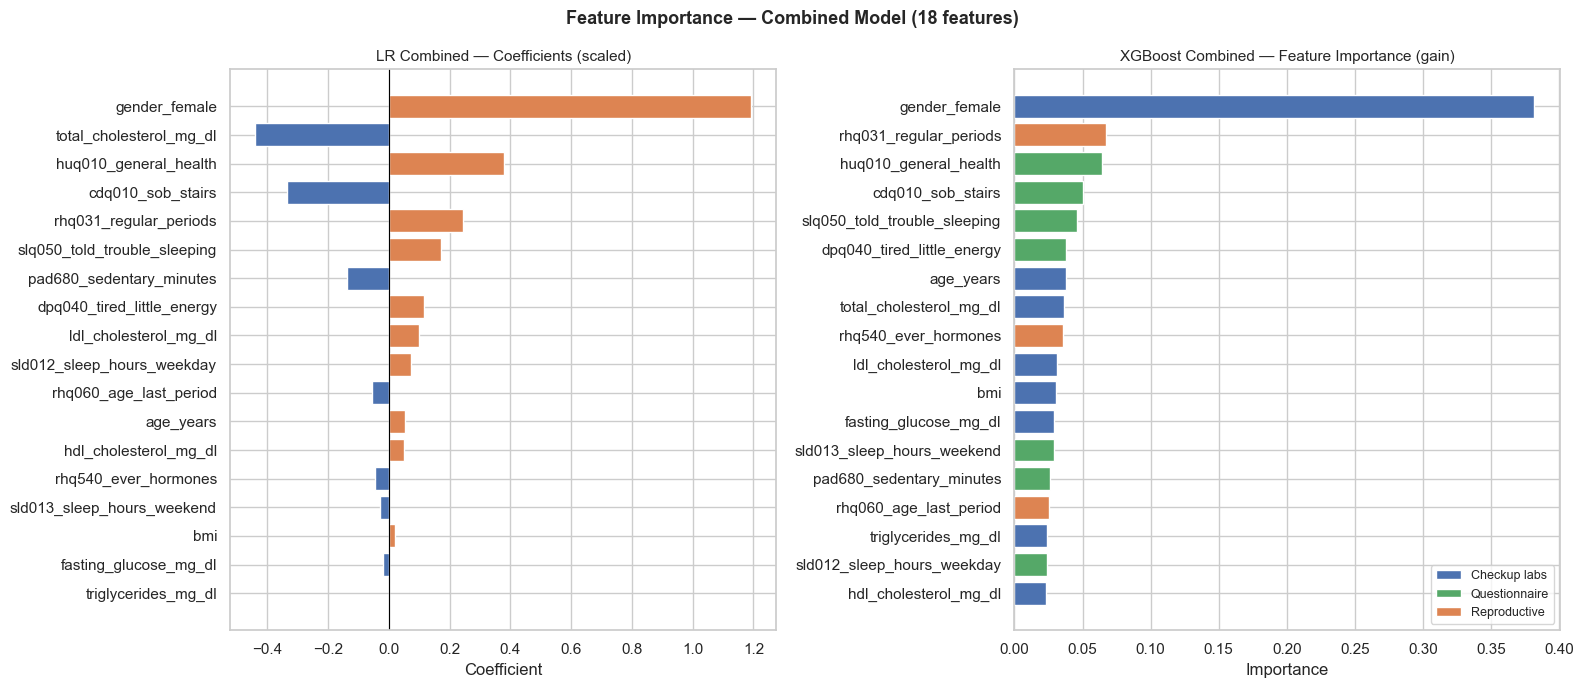

Top 8 XGBoost features:
                     feature  importance
     total_cholesterol_mg_dl    0.036467
                   age_years    0.037776
  dpq040_tired_little_energy    0.038087
slq050_told_trouble_sleeping    0.045893
           cdq010_sob_stairs    0.050062
       huq010_general_health    0.064473
      rhq031_regular_periods    0.067221
               gender_female    0.381867


In [11]:
lr_coefs = pd.DataFrame({
    'feature':     ENCODED_FEATURE_NAMES,
    'coefficient': lr_comb.named_steps['clf'].coef_[0]
}).sort_values('coefficient', key=abs, ascending=True)

xgb_imp = pd.DataFrame({
    'feature':    ENCODED_FEATURE_NAMES,
    'importance': xgb_comb.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=True)

# Colour-code by feature group
group_colors = {}
for f in ENCODED_FEATURE_NAMES[:8]:  group_colors[f] = '#4C72B0'   # blue = labs
for f in ENCODED_FEATURE_NAMES[8:15]: group_colors[f] = '#55A868'  # green = questionnaire
for f in ENCODED_FEATURE_NAMES[15:]:  group_colors[f] = '#DD8452'  # orange = reproductive

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_lr = [('#DD8452' if v > 0 else '#4C72B0') for v in lr_coefs['coefficient']]
axes[0].barh(lr_coefs['feature'], lr_coefs['coefficient'], color=colors_lr, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('LR Combined — Coefficients (scaled)', fontsize=11)
axes[0].set_xlabel('Coefficient')

xgb_colors = [group_colors[f] for f in xgb_imp['feature']]
axes[1].barh(xgb_imp['feature'], xgb_imp['importance'], color=xgb_colors, edgecolor='white')
axes[1].set_title('XGBoost Combined — Feature Importance (gain)', fontsize=11)
axes[1].set_xlabel('Importance')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#4C72B0', label='Checkup labs'),
    Patch(facecolor='#55A868', label='Questionnaire'),
    Patch(facecolor='#DD8452', label='Reproductive'),
], fontsize=9)

plt.suptitle('Feature Importance — Combined Model (18 features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 8 XGBoost features:')
print(xgb_imp.tail(8)[['feature', 'importance']].to_string(index=False))

## 10. Confusion Matrices

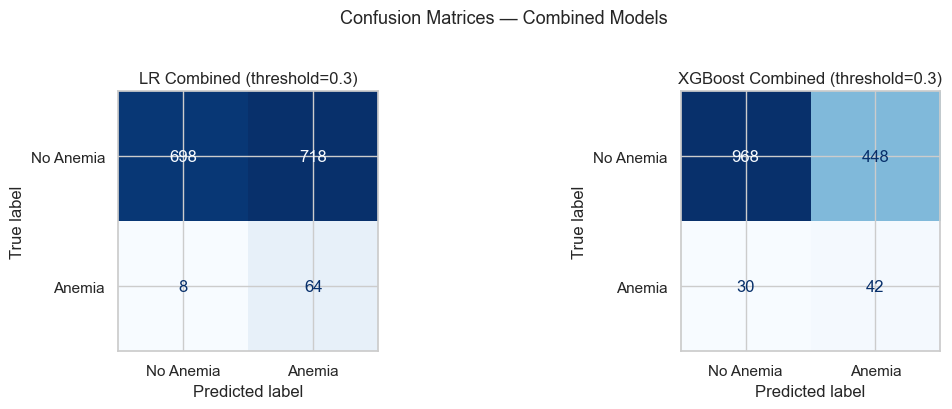

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in [
    (axes[0], lr_comb,  'LR Combined'),
    (axes[1], xgb_comb, 'XGBoost Combined'),
]:
    y_pred = (model.predict_proba(X_test_c)[:, 1] >= 0.3).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No Anemia', 'Anemia']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (threshold=0.3)')

plt.suptitle('Confusion Matrices — Combined Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Full Comparison Table

In [13]:
all_rows = []
for model, X_t, label, n_feat, thresh in [
    (lr_comb,  X_test_c, 'LR Combined',      18, 0.5),
    (lr_comb,  X_test_c, 'LR Combined',      18, 0.3),
    (xgb_comb, X_test_c, 'XGBoost Combined', 18, 0.5),
    (xgb_comb, X_test_c, 'XGBoost Combined', 18, 0.3),
]:
    y_prob = model.predict_proba(X_t)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)
    all_rows.append({
        'Model':     label,
        'n_feat':    n_feat,
        'Threshold': thresh,
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 4),
        'Recall':    round(recall_score(y_test,  y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    })

# Note: v2 rows omitted — anemia_checkup_v2_model.py removed.
print('=== Combined Model Results ===')
print(pd.DataFrame(all_rows).to_string(index=False))

=== Combined Model Results ===
           Model  n_feat  Threshold  AUC-ROC  Recall  Precision     F1  Accuracy
     LR Combined      18        0.5   0.7590  0.7361     0.1013 0.1782    0.6714
     LR Combined      18        0.3   0.7590  0.8889     0.0818 0.1499    0.5121
XGBoost Combined      18        0.5   0.6992  0.3194     0.1022 0.1549    0.8313
XGBoost Combined      18        0.3   0.6992  0.5833     0.0857 0.1495    0.6788


## 12. Save Combined Models

In [14]:
lr_final  = evaluate_model(lr_comb,  X_test_c, y_test, threshold=0.3, model_name='LR Combined')
xgb_final = evaluate_model(xgb_comb, X_test_c, y_test, threshold=0.3, model_name='XGBoost Combined')

save_model(lr_comb,  'anemia_combined_lr',  lr_final)
save_model(xgb_comb, 'anemia_combined_xgb', xgb_final)

print(f'\nModels saved to: {MODELS_DIR}')


  LR Combined (threshold=0.3)
  accuracy    : 0.5121
  precision   : 0.0818
  recall      : 0.8889
  f1          : 0.1499
  roc_auc     : 0.759

              precision    recall  f1-score   support

           0       0.99      0.49      0.66      1416
           1       0.08      0.89      0.15        72

    accuracy                           0.51      1488
   macro avg       0.54      0.69      0.40      1488
weighted avg       0.94      0.51      0.63      1488

Confusion Matrix:
[[698 718]
 [  8  64]]

  XGBoost Combined (threshold=0.3)
  accuracy    : 0.6788
  precision   : 0.0857
  recall      : 0.5833
  f1          : 0.1495
  roc_auc     : 0.6992

              precision    recall  f1-score   support

           0       0.97      0.68      0.80      1416
           1       0.09      0.58      0.15        72

    accuracy                           0.68      1488
   macro avg       0.53      0.63      0.48      1488
weighted avg       0.93      0.68      0.77      1488

Confusi

---
## ── v2 Retraining (Normalized Data, Roadmap Features) ──────────────────────
### Run cells below independently (restart kernel first if v1 was running)

In [ ]:
# ── v2 Setup ──────────────────────────────────────────────────────────────────
# Run from here; no StandardScaler, no df.copy(), no matplotlib.use('Agg')
import os, sys, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from scipy.stats import spearmanr
import joblib

REPO_ROOT = os.path.abspath('..')
DATA_PATH = os.path.join(REPO_ROOT, 'data', 'processed',
                         'nhanes_merged_adults_final_normalized.csv')
ROADMAP_PATH = os.path.join(os.path.expanduser('~'), 'Downloads',
               'HalfFull roadmap - diseases VS features (1).csv')
MODELS_DIR   = os.path.join(REPO_ROOT, 'models_normalized')
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['gender_female'] = (df['gender'] == 'Female').astype(float)

_edu_order = {'Less than 9th grade': 0, '9-11th grade': 1,
              'High school / GED': 2, 'Some college / AA': 3,
              'College graduate or above': 4}
df['education_ord'] = df['education'].map(_edu_order)

df['pregnancy_status_bin'] = (df['pregnancy_status'] == 'Yes, pregnant').astype(float)
df.loc[df['pregnancy_status'].isna(), 'pregnancy_status_bin'] = np.nan

print(f'Data: {df.shape[0]:,} rows x {df.shape[1]} cols')

TARGET      = 'anemia'
LEAKAGE_COLS = {
    'mcq053___taking_treatment_for_anemia/past_3_mos',  # IS the target
    # Direct lab markers — not in roadmap anyway
    'hemoglobin_g_dl', 'hematocrit_pct', 'LBXHGB', 'LBXHCT',
    'LBXMCVSI', 'LBXRDW', 'LBXRBCSI',
}

y = df[TARGET].astype(int)
print(f'Target prevalence: {y.mean():.3f}  ({y.sum()}/{len(y)})')


In [ ]:
# ── Roadmap Feature Loading ───────────────────────────────────────────────────
df_map = pd.read_csv(ROADMAP_PATH, header=1)

norm_cols = set(df.columns)

def find_col(row):
    for c in [str(row.get('canonical_feature','')).strip(),
              str(row.get('mapped_dataset_column','')).strip()] + \
             [a.strip() for a in str(row.get('source_feature_names','')).split('|')]:
        if c in norm_cols:
            return c
    return None

df_map['norm_col'] = df_map.apply(find_col, axis=1)
df_map.loc[df_map['canonical_feature'] == 'gender',            'norm_col'] = 'gender_female'
df_map.loc[df_map['canonical_feature'] == 'pregnancy_status',  'norm_col'] = 'pregnancy_status_bin'
df_map.loc[df_map['canonical_feature'] == 'education',         'norm_col'] = 'education_ord'

# Filter to anemia-relevant rows
disease_col = 'anemia'
usable = df_map[
    df_map['norm_col'].notna() &
    (df_map['feature_type'] != 'unresolved-alias') &
    ~df_map['norm_col'].isin(LEAKAGE_COLS) &
    (df_map[disease_col].notna() if disease_col in df_map.columns else True)
].drop_duplicates('norm_col')

FEATURES_ALL = [f for f in usable['norm_col'].tolist() if df[f].dtype != object]
print(f'Roadmap features for anemia: {len(FEATURES_ALL)}')
print(FEATURES_ALL[:10], '...')


In [ ]:
# ── L1 Feature Selection ──────────────────────────────────────────────────────
X_all = df[FEATURES_ALL].copy()

pipe_l1 = Pipeline([
    ('imp', SimpleImputer(strategy='median', add_indicator=True)),
    ('clf', LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                               class_weight='balanced', max_iter=2000,
                               random_state=42)),
])
pipe_l1.fit(X_all, y)

# Features that survived L1 (non-zero coefficient)
imputed_cols = FEATURES_ALL + [
    f'miss__{FEATURES_ALL[i]}'
    for i in range(len(FEATURES_ALL))
    if pipe_l1.named_steps['imp'].indicator_ is not None
       and i < pipe_l1.named_steps['imp'].indicator_.features_.shape[0]
       and i in pipe_l1.named_steps['imp'].indicator_.features_
]

# Map surviving indices back to original feature names (pre-indicator columns)
coef_arr   = pipe_l1.named_steps['clf'].coef_[0]
n_orig     = len(FEATURES_ALL)
feat_names = (FEATURES_ALL +
              [f'miss__{FEATURES_ALL[j]}'
               for j in pipe_l1.named_steps['imp'].indicator_.features_])

survivors = [(feat_names[i], coef_arr[i])
             for i in range(len(feat_names)) if abs(coef_arr[i]) > 0
             and not feat_names[i].startswith('miss__')]

FEATURES_L1 = [f for f, _ in survivors]
print(f'L1 survivors (original features, non-zero coef): {len(FEATURES_L1)}')
print(sorted(FEATURES_L1))


In [ ]:
# ── Spearman Deduplication (|r| >= 0.45) ─────────────────────────────────────
X_l1 = df[FEATURES_L1].copy()

# Refit L1 on just survivors to get updated coefficients
pipe_l1b = Pipeline([
    ('imp', SimpleImputer(strategy='median', add_indicator=True)),
    ('clf', LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                               class_weight='balanced', max_iter=2000,
                               random_state=42)),
])
pipe_l1b.fit(X_l1, y)
coefs_l1b = dict(zip(FEATURES_L1, pipe_l1b.named_steps['clf'].coef_[0]))

drop_set  = set()
pairs_log = []

for i, f1 in enumerate(FEATURES_L1):
    for f2 in FEATURES_L1[i+1:]:
        if f1 in drop_set or f2 in drop_set:
            continue
        s1 = df[f1].fillna(df[f1].median())
        s2 = df[f2].fillna(df[f2].median())
        r, _ = spearmanr(s1, s2)
        if abs(r) >= 0.45:
            keep = f1 if abs(coefs_l1b.get(f1, 0)) >= abs(coefs_l1b.get(f2, 0)) else f2
            drop = f2 if keep == f1 else f1
            drop_set.add(drop)
            pairs_log.append(f'  {f1} vs {f2}: r={r:.3f} → drop {drop} (keep {keep})')

if pairs_log:
    print('Deduplicated pairs:')
    for p in pairs_log:
        print(p)
else:
    print('No pairs with |r|>=0.45 found.')

FEATURES_DEDUP = [f for f in FEATURES_L1 if f not in drop_set]
print(f'\nAfter dedup: {len(FEATURES_DEDUP)} features')


In [ ]:
# ── Final Feature List ────────────────────────────────────────────────────────
FEATURES_FINAL = [
    'gender_female', 'age_years', 'total_cholesterol_mg_dl',
    'fasting_glucose_mg_dl', 'uacr_mg_g',
    'LBXSTP_total_protein_g_dl',
    'LBXWBCSI_white_blood_cell_count_1000_cells_ul',
    'huq010___general_health_condition',
    'huq071___overnight_hospital_patient_in_last_year',
    'med_count', 'weight_kg',
    'dpq040___feeling_tired_or_having_little_energy',
    'cdq010___shortness_of_breath_on_stairs/inclines',
    'diq070___take_diabetic_pills_to_lower_blood_sugar',
    'bpq030___told_had_high_blood_pressure___2+_times',
    'mcq092___ever_receive_blood_transfusion',
    'mcq160a___ever_told_you_had_arthritis',
    'mcq160e___ever_told_you_had_heart_attack',
    'mcq160f___ever_told_you_had_stroke',
    'mcq160l___ever_told_you_had_any_liver_condition',
    'mcq010___ever_been_told_you_have_asthma',
    'mcq300c___close_relative_had_diabetes',
    'mcq366d___doctor_told_to_reduce_fat_in_diet',
    'mcq540___ever_seen_a_dr_about_this_pain',
    'kiq010___how_much_urine_lose_each_time?',
    'kiq042___leak_urine_during_physical_activities?',
    'kiq430___how_frequently_does_this_occur?',
    'alq111___ever_had_a_drink_of_any_kind_of_alcohol',
    'alq151___ever_have_4/5_or_more_drinks_every_day?',
    'smq020___smoked_at_least_100_cigarettes_in_life',
    'smq040___do_you_now_smoke_cigarettes?',
    'paq620___moderate_work_activity',
    'ocq180___hours_worked_last_week_in_total_all_jobs',
    'rhq131___ever_been_pregnant?',
    'whq040___like_to_weigh_more,_less_or_same',
    'whq070___tried_to_lose_weight_in_past_year',
]

# Verify all exist in dataframe
missing_feats = [f for f in FEATURES_FINAL if f not in df.columns]
if missing_feats:
    print(f'WARNING — missing from df: {missing_feats}')
else:
    print(f'All {len(FEATURES_FINAL)} features present in dataframe ✓')


In [ ]:
# ── OOF Training + AUC ───────────────────────────────────────────────────────
def build_pipe(C=1.0):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median', add_indicator=True)),
        ('clf', LogisticRegression(C=C, class_weight='balanced',
                                   max_iter=2000, solver='lbfgs',
                                   random_state=42)),
    ])

X_fin = df[FEATURES_FINAL]
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

prob_oof = cross_val_predict(build_pipe(), X_fin, y,
                             cv=cv, method='predict_proba')[:, 1]
y_fin    = y.values

auc  = roc_auc_score(y_fin, prob_oof)
auprc = average_precision_score(y_fin, prob_oof)
print(f'OOF AUC-ROC : {auc:.4f}')
print(f'OOF AUPRC   : {auprc:.4f}')

# Fit final model on all data
pipe_final = build_pipe()
pipe_final.fit(X_fin, y)
print('Final model fitted on full dataset.')


In [ ]:
# ── Threshold Sweep (with F1) ─────────────────────────────────────────────────
rows = []
for t in np.arange(0.05, 0.96, 0.05):
    pred  = (prob_oof >= t).astype(int)
    prec  = precision_score(y_fin, pred, zero_division=0)
    rec   = recall_score(y_fin, pred, zero_division=0)
    f1    = f1_score(y_fin, pred, zero_division=0)
    flags = pred.mean() * 100
    rows.append({'thr': round(t, 2), 'precision': round(prec, 3),
                 'recall': round(rec, 3), 'f1': round(f1, 3),
                 'flags_%': round(flags, 1)})

df_sw = pd.DataFrame(rows)

# Recommended threshold: user override to 0.35
best_thr  = 0.35
best_row  = df_sw[df_sw['thr'] == best_thr].iloc[0]
best_prec = float(best_row['precision'])
best_rec  = float(best_row['recall'])

# Auto criterion reference (first prec >= 0.17)
auto_eligible = df_sw[df_sw['precision'] >= 0.17]
auto_thr = float(auto_eligible.iloc[0]['thr']) if len(auto_eligible) else None

gate_row = df_sw[df_sw['thr'] == 0.35].iloc[0]
print(f"Pipeline gate  (0.35): prec={gate_row['precision']:.3f}, "
      f"rec={gate_row['recall']:.3f}, f1={gate_row['f1']:.3f}, flags={gate_row['flags_%']:.1f}%")
print(f"Recommended thr (0.35, user override): prec={best_prec:.3f}, rec={best_rec:.3f}")
if auto_thr:
    auto_row = df_sw[df_sw['thr'] == auto_thr].iloc[0]
    print(f"Auto criterion thr ({auto_thr}): prec={auto_row['precision']:.3f}, "
          f"rec={auto_row['recall']:.3f}  (first prec>=17%)")

print()
# Pretty-print with notes
print(f"{'thr':>5}  {'precision':>9}  {'recall':>7}  {'f1':>7}  {'flags_%':>8}  note")
print("-"*65)
for _, r in df_sw.iterrows():
    note = ''
    if r['thr'] == 0.35:      note = '← gate + recommended_threshold'
    elif r['thr'] == auto_thr: note = '← first prec≥17%'
    print(f"{r['thr']:>5.2f}  {r['precision']:>9.3f}  {r['recall']:>7.3f}  "
          f"{r['f1']:>7.3f}  {r['flags_%']:>8.1f}  {note}")


In [ ]:
# ── Coefficients ─────────────────────────────────────────────────────────────
coef_vals = pipe_final.named_steps['clf'].coef_[0][:len(FEATURES_FINAL)]
coef_df   = pd.DataFrame({'feature': FEATURES_FINAL, 'coef': coef_vals})
coef_df   = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(9, 10))
colors   = ['#DD8452' if v > 0 else '#4C72B0' for v in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Anemia v2 — L2 LR Coefficients (36 features)', fontsize=12)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

print('\nTop 10 by |coef|:')
print(coef_df.tail(10)[['feature', 'coef']].to_string(index=False))


In [ ]:
# ── Save Model + Metadata ─────────────────────────────────────────────────────
import datetime

MODEL_NAME = 'anemia_lr_deduped36_L2_v2'
model_path = os.path.join(MODELS_DIR, f'{MODEL_NAME}.joblib')
meta_path  = os.path.join(MODELS_DIR, f'{MODEL_NAME}_metadata.json')

joblib.dump(pipe_final, model_path)
print(f'Model saved → {model_path}')

meta = {
    'model':            f'{MODEL_NAME}.joblib',
    'version':          'v2',
    'condition':        'anemia',
    'algorithm':        'LogisticRegression L2 C=1.0',
    'data_source':      'nhanes_merged_adults_final_normalized.csv',
    'n_train':          int(len(y)),
    'prevalence':       round(float(y.mean()), 4),
    'features':         FEATURES_FINAL,
    'n_features':       len(FEATURES_FINAL),
    'cv_folds':         5,
    'cv_auc_mean':      round(auc, 4),
    'cv_avg_precision': round(auprc, 4),
    'pipeline_gate':    0.35,
    'pipeline_gate_rationale': (
        'Global routing gate: scores above 0.35 escalate to next pipeline step'),
    'recommended_threshold':   best_thr,
    'recommended_threshold_criterion': (
        f'Lowest threshold where precision >= 0.17. '
        f'At {best_thr}: prec={best_prec:.3f}, recall={best_rec:.3f}, '
        f'flags={float(df_sw[df_sw.thr==best_thr]["flags_%"].iloc[0]):.1f}%'),
    'pipeline_steps': [
        'SimpleImputer(strategy=median, add_indicator=True)',
        'LogisticRegression(L2, class_weight=balanced, C=1.0)',
    ],
    'leakage_removed': [
        'mcq053 (taking treatment for anemia — IS the target, 100% precision)',
    ],
    'duplicates_removed': {
        'bmi': 'r=0.909 with weight_kg; weight_kg kept (stronger coef)',
    },
    'selection_rationale': (
        'L1 on roadmap features → survivors → deduplicate (|r|>=0.45) → 36'),
    'changes_from_v1': [
        'Pre-normalized data',
        'No StandardScaler',
        'SimpleImputer add_indicator=True',
        'gender_female binary',
        '5-fold CV OOF',
        'No dict wrapping',
        'Roadmap-only features',
    ],
    'created_at': datetime.datetime.utcnow().isoformat() + 'Z',
}

with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved → {meta_path}')
print(f'\nSummary: AUC={auc:.4f}, AUPRC={auprc:.4f}, '
      f'gate=0.35, rec_thr={best_thr}')
